<a href="https://colab.research.google.com/github/Arundhuti2000/signature-forgery-detection/blob/main/signature_verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub
import os
import cv2
import random
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
def load_images(folder_path, folder_type, target_size=(128, 128), sample_count=5):
    images = []
    labels = []
    all_filenames = []
    sample_images = []
    sample_labels = []

    if not os.path.isdir(folder_path):
        print(f"Warning: Folder {folder_path} does not exist.")
        return np.array(images), np.array(labels), all_filenames

    print(f"Loading images from subfolders of: {folder_path}")

    for root, _, files in os.walk(folder_path):
        for filename in files:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(root, filename)
                try:
                    img = load_img(img_path, target_size=target_size)
                    img = img_to_array(img)
                    img = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
                    img_array = img / 255.0
                    img_array = np.expand_dims(img_array, axis=-1)

                    if len(sample_images) < sample_count:
                        sample_images.append(img_array)
                        sample_labels.append('Real' if folder_type.lower() == 'real' else 'Forged')

                    images.append(img_array)
                    labels.append(1 if folder_type.lower() == 'real' else 0)
                    all_filenames.append(img_path)
                except Exception as e:
                    print(f"Error processing file {img_path}: {e}")

    if sample_images:
        fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 5))
        for ax, sample_img, sample_label in zip(axes, sample_images, sample_labels):
            ax.imshow(sample_img.squeeze(), cmap='gray')
            ax.set_title(sample_label, fontsize=10)  # Use label instead of filename
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    print(f"Total images loaded: {len(images)}")
    return np.array(images), np.array(labels), all_filenames

In [15]:
path = kagglehub.dataset_download("tienen/handwritten-signature-verification")

In [17]:
# ...existing code...

f_data = "/kaggle/input/handwritten-signature-verification/data/data/forged"
r_data = "/kaggle/input/handwritten-signature-verification/data/data/real"

# ...existing code...

Loading images from subfolders of: /kaggle/input/handwritten-signature-verification/data/data/forged
Error processing file /kaggle/input/handwritten-signature-verification/data/data/forged/ru.d1c664d6-431d-4985-9e21-5989b1b7df4b__0001e12109--61ff34f8f73c4b173c32986d__JP A.jpg: cannot identify image file <_io.BytesIO object at 0x7fb0eca8ff60>


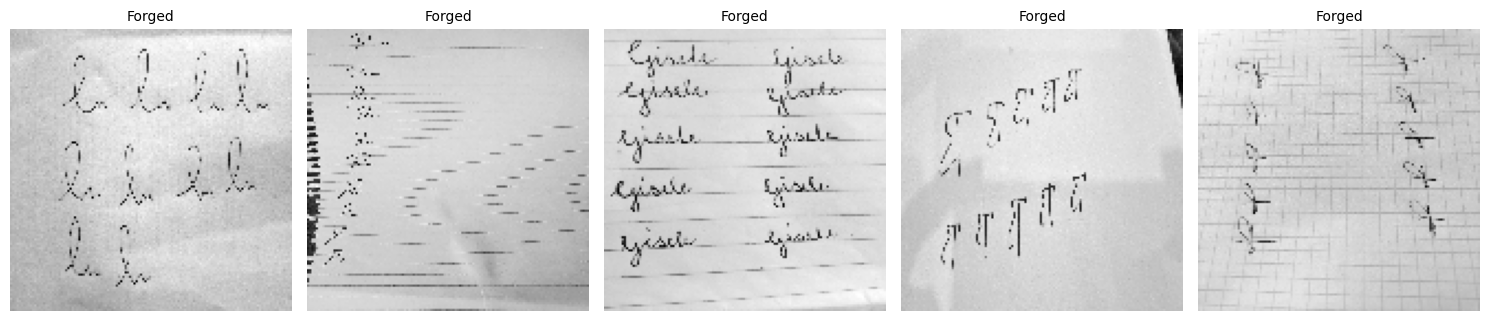

Total images loaded: 2983
Loading images from subfolders of: /kaggle/input/handwritten-signature-verification/data/data/real


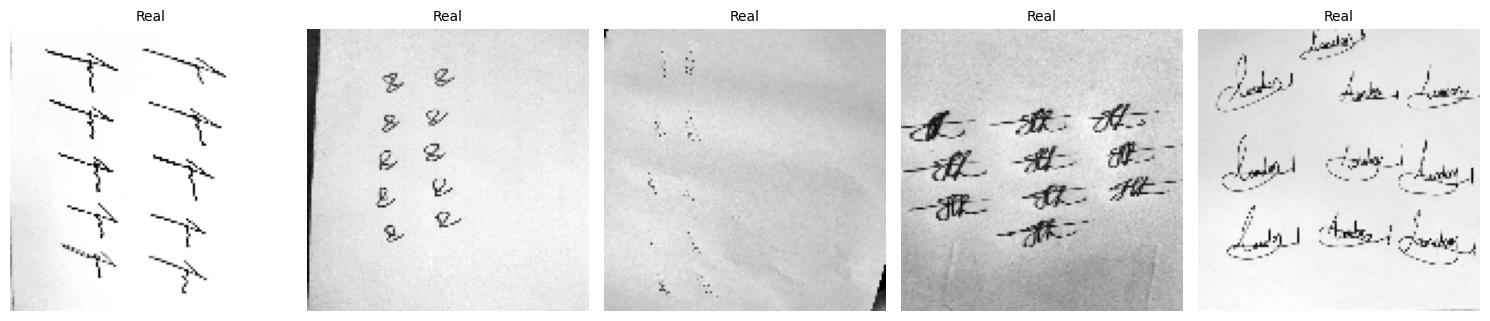

Total images loaded: 3188


In [18]:
imgs_f, labels_f, k = load_images(f_data, "forged")
imgs_r, labels_r, l = load_images(r_data, "real")

In [19]:
all_images = np.concatenate((imgs_f, imgs_r), axis=0)
all_labels = np.concatenate((labels_f, labels_r), axis=0)


all_images, all_labels = shuffle(all_images, all_labels, random_state=42)

In [20]:
all_labels = to_categorical(all_labels,num_classes = 2)

In [21]:
all_labels.shape

(6171, 2)

In [22]:
all_images.shape

(6171, 128, 128, 1)

In [23]:
x_train, x_test, y_train, y_test = train_test_split(all_images, all_labels, test_size=0.3, random_state=42)

In [24]:
print(x_train.shape)
x_test.shape

(4319, 128, 128, 1)


(1852, 128, 128, 1)

In [25]:
train_datagen = ImageDataGenerator(
    rotation_range=35,
    width_shift_range=0.3,
    height_shift_range=0.2,
    shear_range=0.3,
    horizontal_flip=True,
)


train_generator = train_datagen.flow(x_train, y_train, batch_size=128)

In [26]:
def plot_train(hist):
    history = hist.history

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    axes[0].plot(history['loss'], label='Training Loss')
    axes[0].plot(history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss Over Epochs')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid()

    if 'accuracy' in history:  # Adjust for older versions with 'acc'
        axes[1].plot(history['accuracy'], label='Training Accuracy')
        axes[1].plot(history['val_accuracy'], label='Validation Accuracy')
        axes[1].set_title('Model Accuracy Over Epochs')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid()


    plt.tight_layout()
    plt.show()

In [27]:
base_model = ResNet50(include_top=False, weights=None, input_shape=(128, 128, 1))

for layer in base_model.layers[:30]:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu',kernel_regularizer= tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu',kernel_regularizer= tf.keras.regularizers.l2(0.01))(x)
predictions = Dense(2, activation='softmax')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=predictions)


In [28]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model with early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=(x_test,y_test),
    epochs=25,
    callbacks=[early_stopping],
    batch_size = 128
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.5008 - loss: 4.7513 - val_accuracy: 0.4951 - val_loss: 4.4672
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 376ms/step - accuracy: 0.5132 - loss: 4.3969 - val_accuracy: 0.4951 - val_loss: 4.1435
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 377ms/step - accuracy: 0.5477 - loss: 4.0582 - val_accuracy: 0.4951 - val_loss: 3.8453
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - accuracy: 0.5509 - loss: 3.7544 - val_accuracy: 0.4951 - val_loss: 3.5894
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - accuracy: 0.5475 - loss: 3.4804 - val_accuracy: 0.4951 - val_loss: 3.3203
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 344ms/step - accuracy: 0.5675 - loss: 3.2204 - val_accuracy: 0.4951 - val_loss: 3.1103
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 351ms/step - accuracy: 0.5612 - loss: 2.9921 - val_accuracy: 0.4951 - val_loss: 2.9261
Epoch 8/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 348ms/step - accuracy: 0.5755 - loss: 2.7732 - val_accura

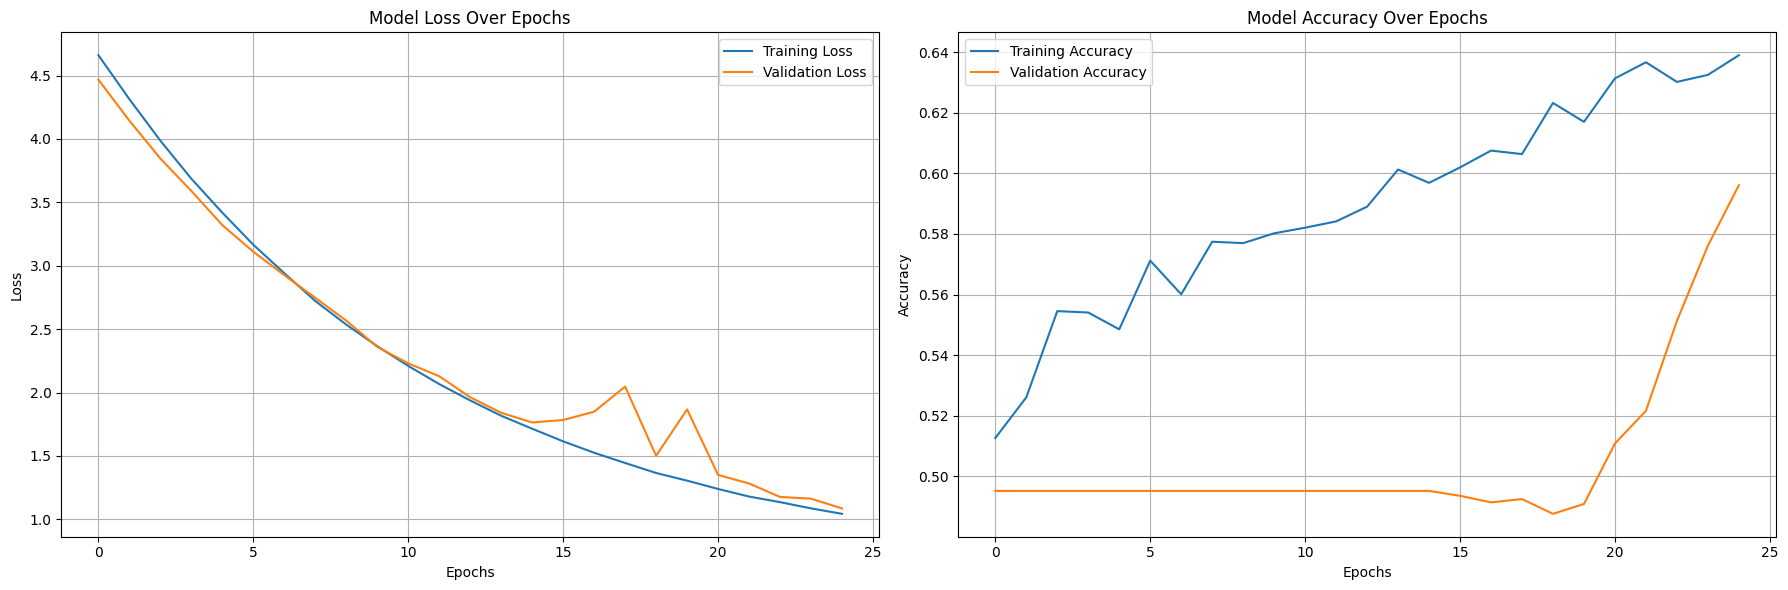

In [29]:
plot_train(history)

In [30]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile the model after unfreezing
model.compile(optimizer=Adam(learning_rate=0.00001),  # Lower learning rate for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_tuned = model.fit(
    train_generator,
    validation_data=(x_test,y_test),
    epochs=100,
    callbacks=[early_stopping],
    batch_size = 128
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6504 - loss: 1.0051 - val_accuracy: 0.6210 - val_loss: 1.0400
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 351ms/step - accuracy: 0.6675 - loss: 0.9927 - val_accuracy: 0.6420 - val_loss: 1.0162
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 414ms/step - accuracy: 0.6676 - loss: 0.9844 - val_accuracy: 0.6577 - val_loss: 0.9969
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 366ms/step - accuracy: 0.6586 - loss: 0.9809 - val_accuracy: 0.6609 - val_loss: 0.9840
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 356ms/step - accuracy: 0.6650 - loss: 0.9732 - val_accuracy: 0.6690 - val_loss: 0.9719
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - accuracy: 0.6844 - loss: 0.9512 - val_accuracy: 0.6782 - val_loss: 0.9575
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 350ms/step - accuracy: 0.6685 - loss: 0.9602 - val_accuracy: 0.6776 - val_loss: 0.9503
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 387ms/step - accuracy: 0.6778 - loss: 0.9360 - val

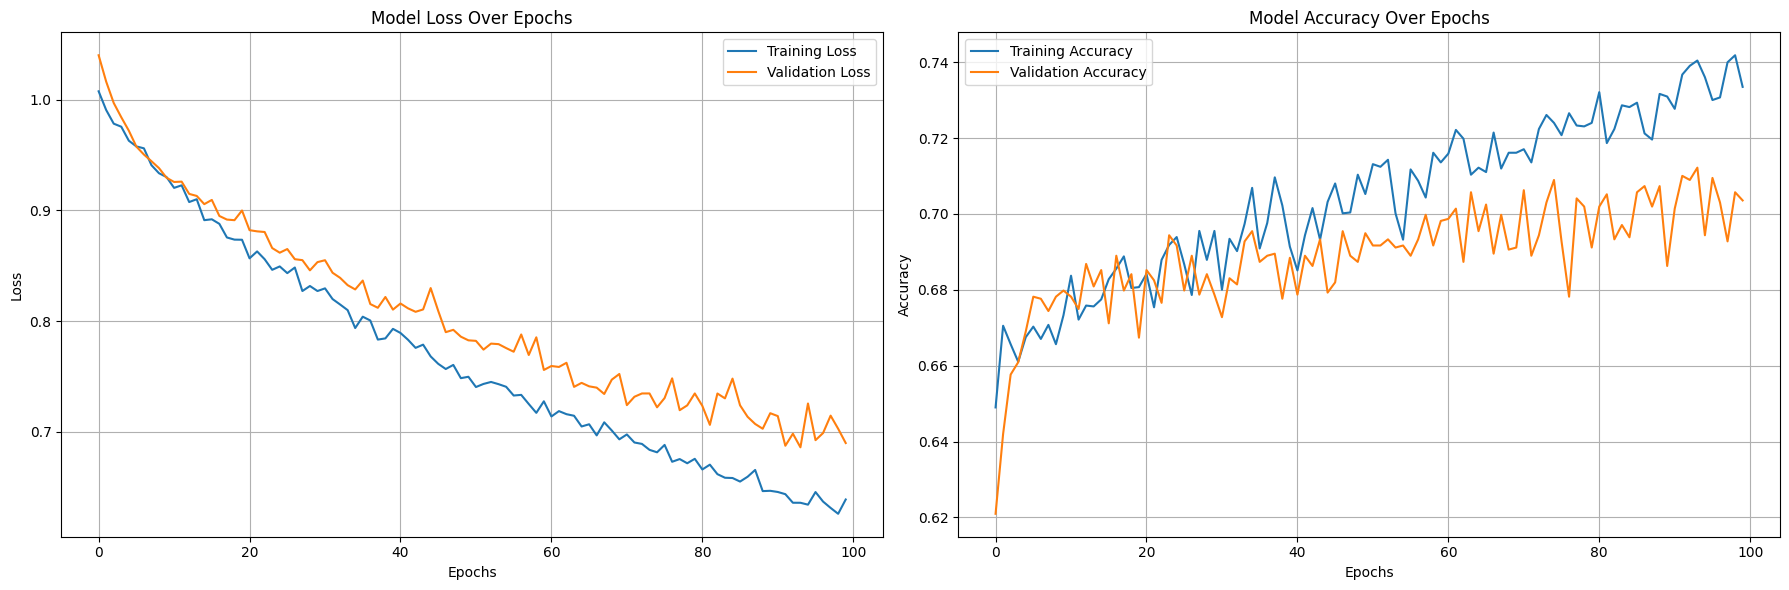

In [31]:
plot_train(history_tuned)

In [32]:
# creating more complex augemtation to prevent over fitting
train_datagen = ImageDataGenerator(
    rotation_range=35,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.4,
    horizontal_flip=True,
)


train_generator = train_datagen.flow(x_train, y_train, batch_size=64)

In [34]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile the model after unfreezing
model.compile(optimizer=Adam(learning_rate=0.00001),  # Lower learning rate for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model with early stopping
history_tuned = model.fit(
    train_generator,
    validation_data=(x_test,y_test),
    epochs=100,
    callbacks=[early_stopping],
    batch_size = 64
)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 95s 609ms/step - accuracy: 0.7129 - loss: 0.6621 - val_accuracy: 0.6976 - val_loss: 0.7100
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 208ms/step - accuracy: 0.7151 - loss: 0.6654 - val_accuracy: 0.6982 - val_loss: 0.7038
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 207ms/step - accuracy: 0.7187 - loss: 0.6542 - val_accuracy: 0.6868 - val_loss: 0.7106
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 208ms/step - accuracy: 0.7349 - loss: 0.6392 - val_accuracy: 0.7068 - val_loss: 0.6957
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 205ms/step - accuracy: 0.7118 - loss: 0.6685 - val_accuracy: 0.7030 - val_loss: 0.7057
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - accuracy: 0.7038 - loss: 0.6622 - val_accuracy: 0.7036 - val_loss: 0.6814
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 208ms/step - accuracy: 0.7281 - loss: 0.6353 - val_accuracy: 0.6992 - val_loss: 0.6792
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 205ms/step - accuracy: 0.7141 - loss: 0.6436 - 

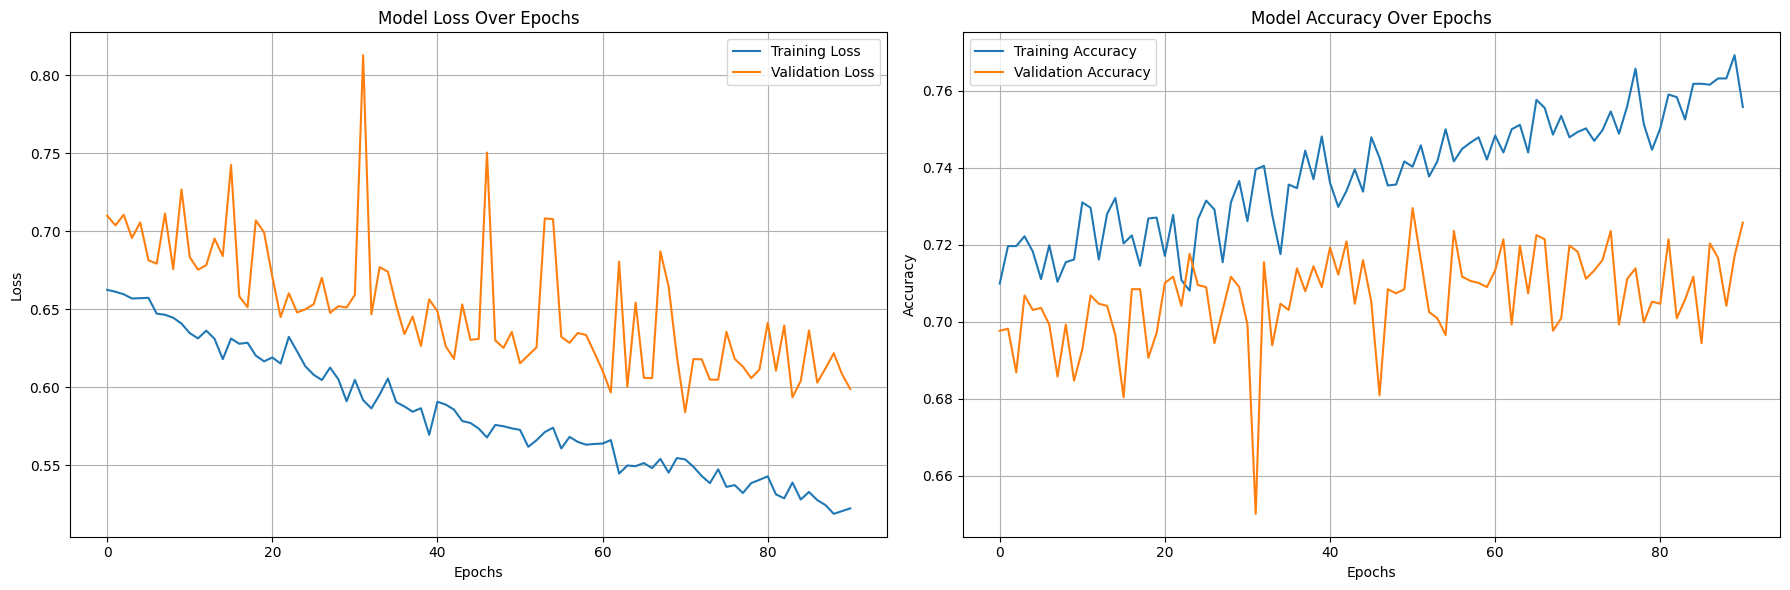

In [35]:
plot_train(history_tuned)

In [36]:
model.evaluate(x_test,y_test)

58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.7149 - loss: 0.5833


[0.5840898752212524, 0.718142569065094]

In [38]:
model.save('fr.h5')
from IPython.display import FileLink
FileLink('fr.h5')

/content/fr.h5

In [40]:
model.save("/home/model/model.keras")